In [33]:
# Compare Linear Regression and Ridge Regression

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MSE": [
        mse,
        ridge_mse
    ],
    "RMSE": [
        rmse,
        ridge_rmse
    ],
    "R2 Score": [
        r2,
        ridge_r2
    ]
})

comparison

,Model,MSE,RMSE,R2 Score
0,Linear Regression,1.401675e+09,37438.945467,0.939244
1,Ridge Regression,1.400737e+09,37426.424625,0.939285


### Conclusion

In this project, a Linear Regression model was developed to predict house prices
using numerical and categorical property features.

The dataset was first explored using descriptive statistics, missing-value analysis,
and visualizations. Important numerical and categorical features were selected based
on their expected relationship with house prices.

Missing values were handled using median imputation for numerical features and
most-frequent imputation for categorical features. Categorical variables were
converted into numerical form using One-Hot Encoding.

The dataset was divided into 80% training data and 20% testing data. A Linear
Regression model was then trained and evaluated using Mean Squared Error (MSE),
Root Mean Squared Error (RMSE), and R² score.

The actual-versus-predicted plot was used to examine prediction accuracy, while the
residual plot was used to check whether the model errors were randomly distributed.

Finally, the regression coefficients were analyzed to identify features with the
strongest positive and negative effects on predicted house prices. A Ridge Regression
model was also tested as a bonus comparison.

Overall, this project demonstrates the complete machine learning workflow from
data cleaning and exploratory data analysis to preprocessing, model training,
evaluation, visualization, and interpretation.  

In [32]:
from sklearn.linear_model import Ridge

# Create Ridge Regression model

ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=1.0))
    ]
)

# Train Ridge model

ridge_model.fit(X_train, y_train)

# Make predictions

ridge_pred = ridge_model.predict(X_test)

# Evaluate Ridge

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Performance")
print("-----------------------------")
print("MSE :", ridge_mse)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

Ridge Regression Performance
-----------------------------
MSE : 1400737260.2093172
RMSE: 37426.42462498011
R²  : 0.9392846421250729


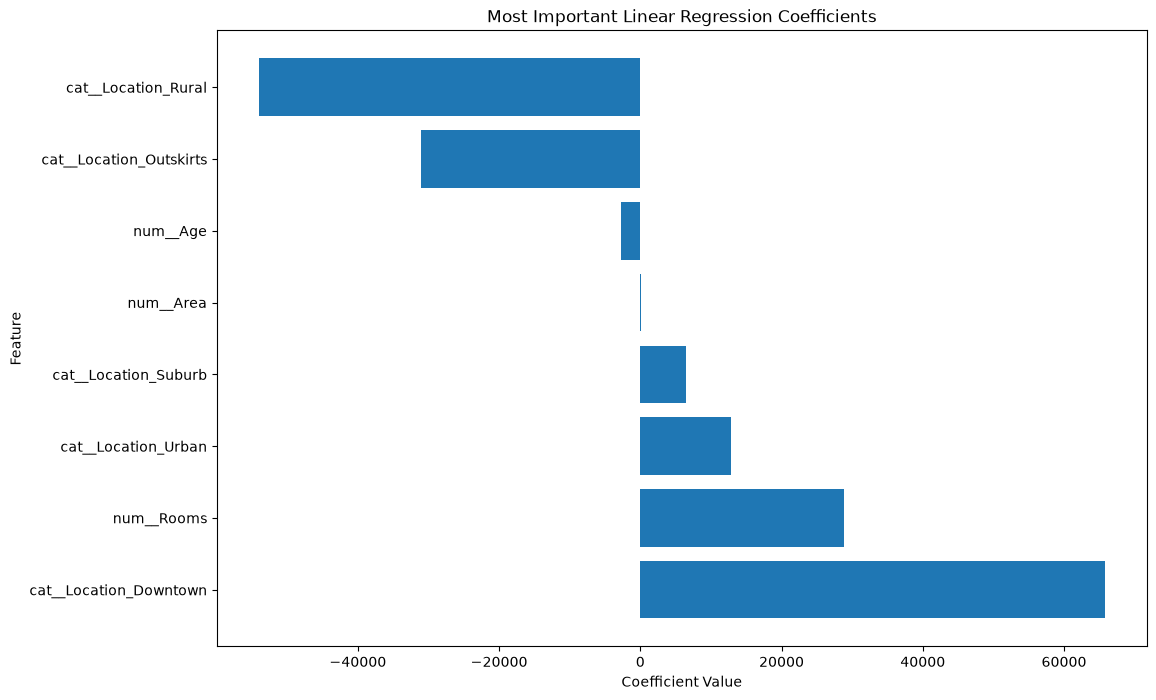

In [31]:
# Select strongest coefficients

top_coefficients = pd.concat([
    coefficient_df.head(10),
    coefficient_df.tail(10)
])

plt.figure(figsize=(12, 8))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Most Important Linear Regression Coefficients")

plt.show()

In [30]:
print("Top 10 Positive Coefficients:")
print(
    coefficient_df.head(10)
)

print("\nTop 10 Negative Coefficients:")
print(
    coefficient_df.tail(10)
)

Top 10 Positive Coefficients:
                   Feature   Coefficient
3   cat__Location_Downtown  65752.119796
1               num__Rooms  28829.695721
7      cat__Location_Urban  12834.304591
6     cat__Location_Suburb   6449.243996
0                num__Area    142.680721
2                 num__Age  -2718.339609
4  cat__Location_Outskirts -31068.178640
5      cat__Location_Rural -53967.489743

Top 10 Negative Coefficients:
                   Feature   Coefficient
3   cat__Location_Downtown  65752.119796
1               num__Rooms  28829.695721
7      cat__Location_Urban  12834.304591
6     cat__Location_Suburb   6449.243996
0                num__Area    142.680721
2                 num__Age  -2718.339609
4  cat__Location_Outskirts -31068.178640
5      cat__Location_Rural -53967.489743


In [29]:
# Get trained preprocessing step

preprocessor_fitted = linear_model.named_steps["preprocessor"]

# Get transformed feature names

feature_names = preprocessor_fitted.get_feature_names_out()

# Get model coefficients

coefficients = linear_model.named_steps["regressor"].coef_

# Create coefficient dataframe

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by coefficient

coefficient_df = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

coefficient_df.head(15)

,Feature,Coefficient
3,cat__Location_Downtown,65752.119796
1,num__Rooms,28829.695721
7,cat__Location_Urban,12834.304591
6,cat__Location_Suburb,6449.243996
0,num__Area,142.680721
2,num__Age,-2718.339609
4,cat__Location_Outskirts,-31068.178640
5,cat__Location_Rural,-53967.489743


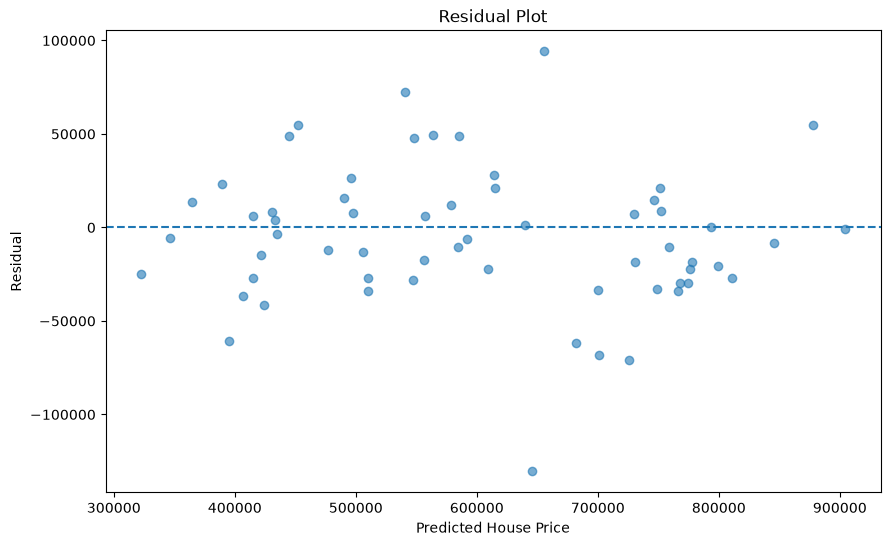

In [28]:
# Calculate residuals

residuals = y_test - y_pred

# Residual plot

plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted House Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

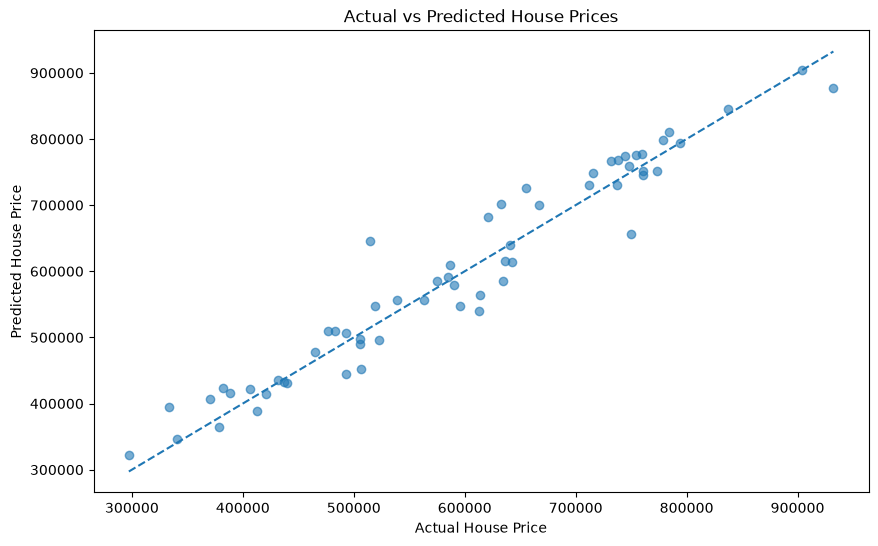

In [27]:
# Actual vs Predicted prices

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Diagonal reference line
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [26]:
# Calculate MSE

mse = mean_squared_error(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R²
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("----------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Performance
----------------------
MSE : 1401674637.6934905
RMSE: 37438.94546716681
R²  : 0.9392440112294494


In [25]:
# Make predictions

y_pred = linear_model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[548140.13056708 776516.93964691 322345.1769894  564164.81335105
 701018.97270183 767781.87143925 640010.08710683 406706.51280279
 389259.55604347 540268.45670056]


In [24]:
# Create Linear Regression model

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

# Train model

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [23]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (240, 4)
Testing data: (60, 4)


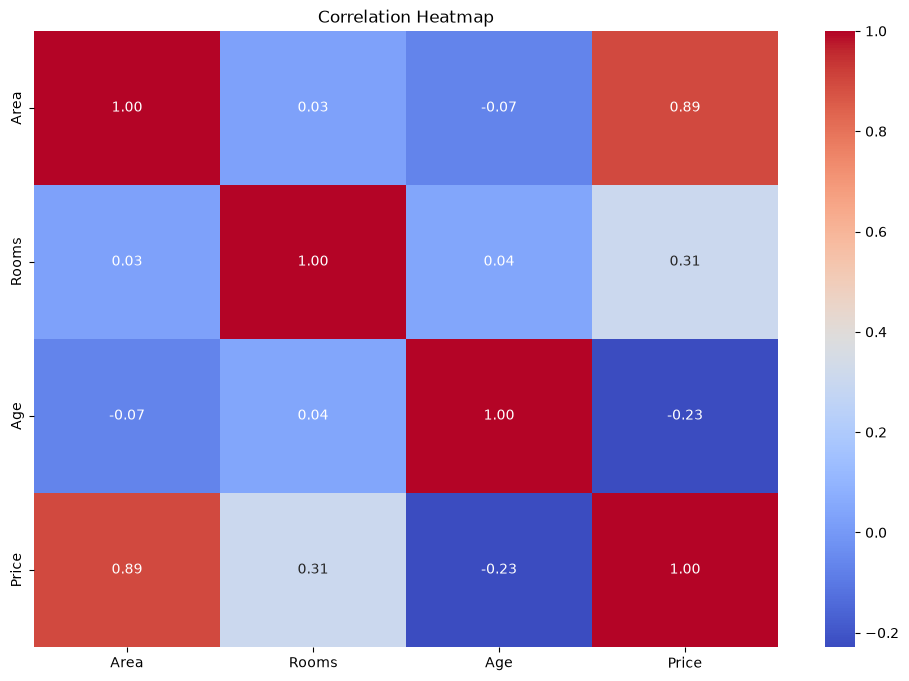

In [22]:
# Correlation matrix

correlation_data = df[
    numerical_features + [target]
].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_data,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [21]:
# Numerical preprocessing

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [18]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Area', 'Rooms', 'Age']

Categorical Features:
['Location']


C:\Users\win11\AppData\Local\Temp\ipykernel_13020\1931058138.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [17]:
# Check missing values in selected features

print(X.isnull().sum())

Area        5
Location    5
Rooms       5
Age         0
dtype: int64


In [16]:
# Select features and target

features = ["Area", "Location", "Rooms", "Age"]
target = "Price"

X = df[features]
y = df[target]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
     Area  Location  Rooms  Age
0  3874.0    Suburb    7.0   28
1  4207.0    Suburb    7.0   12
2  1560.0     Urban    4.0   11
3  1994.0     Urban    2.0   30
4  1830.0  Downtown    2.0    1

Target:
0    774065
1    915695
2    416248
3    344864
4    429218
Name: Price, dtype: int64


### Feature Selection

The features selected for house price prediction include numerical variables such as
GrLivArea, OverallQual, GarageCars, TotalBsmtSF, 1stFlrSF, FullBath, BedroomAbvGr,
and YearBuilt.

These features are likely to influence house prices because larger houses generally
have higher prices, better overall quality usually increases property value, and
features such as garages, bathrooms, bedrooms, basement area, and construction year
can also affect the price.

Categorical features such as Neighborhood, KitchenQual, and GarageType may also affect
house prices because location and property characteristics can significantly influence
market value.

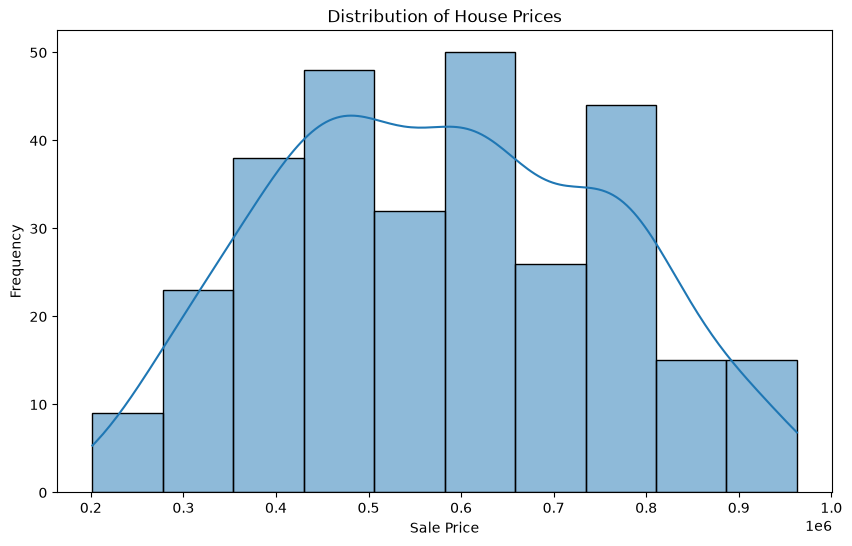

In [12]:
# Distribution of house prices

plt.figure(figsize=(10, 6))

sns.histplot(df["Price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

In [10]:
# Check target vari# Check target variable

print(df["Price"].describe())

count       300.000000
mean     579789.796667
std      176933.610592
min      201690.000000
25%      438850.500000
50%      579931.500000
75%      733687.500000
max      962851.000000
Name: Price, dtype: float64


In [6]:
# Descriptive statistics

df.describe()

,Area,Rooms,Age,Price
count,295.000000,295.000000,300.000000,300.000000
mean,2688.803390,4.471186,19.456667,579789.796667
std,1075.088559,1.737448,11.417647,176933.610592
min,701.000000,2.000000,0.000000,201690.000000
25%,1788.500000,3.000000,10.000000,438850.500000
50%,2681.000000,5.000000,19.500000,579931.500000
75%,3625.000000,6.000000,29.000000,733687.500000
max,4498.000000,7.000000,39.000000,962851.000000


In [5]:
# Check missing values

missing_values = df.isnull().sum()

# Show only columns containing missing values
missing_values = missing_values[missing_values > 0]

print("Columns with missing values:")
print(missing_values)

Columns with missing values:
Area        5
Location    5
Rooms       5
dtype: int64


In [4]:
# Dataset information

print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Shape of dataset: (300, 5)

Column names:
['Area', 'Location', 'Rooms', 'Age', 'Price']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Area      295 non-null    float64
 1   Location  295 non-null    str    
 2   Rooms     295 non-null    float64
 3   Age       300 non-null    int64  
 4   Price     300 non-null    int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 11.8 KB


In [3]:
# Load dataset

df = pd.read_csv("house_price_prediction_dataset.csv")

# Display first 5 rows
df.head()

,Area,Location,Rooms,Age,Price
0,3874.0,Suburb,7.0,28,774065
1,4207.0,Suburb,7.0,12,915695
2,1560.0,Urban,4.0,11,416248
3,1994.0,Urban,2.0,30,344864
4,1830.0,Downtown,2.0,1,429218


In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score